# Prpject : Instruction Following and Evaluation using FLAN-T5

## Overview

This project explores instruction-following using a large language model.

We use the Dolly-15k dataset from Hugging Face and test how well the model can respond to instructions.

The project includes:
- Exploring the dataset (EDA)
- Designing prompts
- Running zero-shot prompting
- Running few-shot prompting
- Comparing the results

## Dataset

The Dolly-15k dataset contains around 15,000 instruction-response pairs created for training and evaluating instruction-following models.

Each example includes:
- Instruction
- Response
- Category

## Model

In this project we use the FLAN-T5 model from Hugging Face to generate responses to instructions.

In [ ]:
# Import libraries for data handling
import pandas as pd
import json

In [ ]:
#Install Hugging Face datasets library
!pip install datasets

In [ ]:
# Load the Dolly-15k instruction datasetfrom datasets import load_dataset

dataset = load_dataset("databricks/databricks-dolly-15k")

dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'context', 'response', 'category'],
        num_rows: 15011
    })
})

In [ ]:
# View a sample from the dataset

dataset["train"][0]

{'instruction': 'When did Virgin Australia start operating?',
 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.",
 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.',
 'category': 'closed_qa'}

In [ ]:
# Convert dataset to pandas DataFrame

import pandas as pd

df = pd.DataFrame(dataset["train"])

# Count number of examples per category

df["category"].value_counts()

,count
category,
open_qa,3742
general_qa,2191
classification,2136
closed_qa,1773
brainstorming,1766
information_extraction,1506
summarization,1188
creative_writing,709


In [ ]:
# Calculate instruction and response length

df["instruction_length"] = df["instruction"].apply(len)
df["response_length"] = df["response"].apply(len)

# Show statistics for instruction and response length

df[["instruction_length","response_length"]].describe()

,instruction_length,response_length
count,15011.000000,15011.000000
mean,71.839384,358.104190
std,134.679885,591.581031
min,4.000000,1.000000
25%,37.000000,78.000000
50%,54.000000,186.000000
75%,81.000000,430.000000
max,11698.000000,26018.000000


In [ ]:
# Create prompt format for instruction-following

def create_prompt(example):

    prompt = f"""
### Instruction:
{example['instruction']}

### Response:
"""

    return prompt

In [ ]:
# Test prompt format on a sample

create_prompt(dataset["train"][0])

'\n### Instruction:\nWhen did Virgin Australia start operating?\n\n### Response:\n'

In [ ]:
# Display instruction and reference response

example = dataset["train"][0]

print("Instruction:")
print(example["instruction"])

print("\nResponse:")
print(example["response"])

Instruction:
When did Virgin Australia start operating?

Response:
Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.


In [ ]:
# Generate prompts for all dataset samples

df["prompt"] = df.apply(
    lambda x: f"### Instruction:\n{x['instruction']}\n\n### Response:\n{x['response']}",
    axis=1
)

df["prompt"].head()

,prompt
0,### Instruction:\nWhen did Virgin Australia st...
1,### Instruction:\nWhich is a species of fish? ...
2,### Instruction:\nWhy can camels survive for l...
3,### Instruction:\nAlice's parents have three d...
4,### Instruction:\nWhen was Tomoaki Komorida bo...


In [ ]:
import matplotlib.pyplot as plt

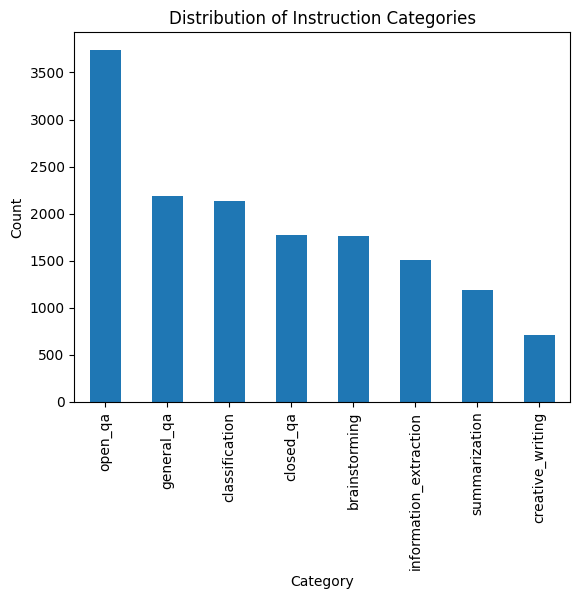

In [ ]:
# Visualize category distribution

df["category"].value_counts().plot(kind="bar")

plt.title("Distribution of Instruction Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [ ]:
# Install transformers library for language models

!pip install transformers torch

In [ ]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 105.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


# Load FLAN-T5 model and tokenizer

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# Import tokenizer and model loader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load the FLAN-T5 model
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# Select one instruction from the dataset for testing
instruction = dataset["train"][0]["instruction"]

print("Instruction:")
print(instruction)

Instruction:
When did Virgin Australia start operating?


In [ ]:
# Tokenize the instruction for the model
inputs = tokenizer(instruction, return_tensors="pt")

# Generate model response using zero-shot prompting
outputs = model.generate(**inputs, max_new_tokens=100)

# Decode the model output
model_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\nModel Answer:")
print(model_answer)


Model Answer:
18 October 2010


In [ ]:
# Get reference answer from dataset
true_answer = dataset["train"][0]["response"]

print("\nTrue Answer:")
print(true_answer)


True Answer:
Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.


# Evaluate model on multiple instructions

In [ ]:

results = []

for i in range(10):

    instruction = dataset["train"][i]["instruction"]
    true_answer = dataset["train"][i]["response"]

    inputs = tokenizer(instruction, return_tensors="pt")
    outputs = model.generate(**inputs, max_new_tokens=100)

    model_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    results.append({
        "instruction": instruction,
        "model_answer": model_answer,
        "true_answer": true_answer
    })

import pandas as pd
results_df = pd.DataFrame(results)

results_df

,instruction,model_answer,true_answer
0,When did Virgin Australia start operating?,18 October 2010,Virgin Australia commenced services on 31 Augu...
1,Which is a species of fish? Tope or Rope,Rope,Tope
2,Why can camels survive for long without water?,a saline environment,Camels use the fat in their humps to keep them...
3,"Alice's parents have three daughters: Amy, Jes...",annie,The name of the third daughter is Alice
4,When was Tomoaki Komorida born?,2 February 1985,"Tomoaki Komorida was born on July 10,1981."
5,If I have more pieces at the time of stalemate...,no,No. \nStalemate is a drawn position. It doesn'...
6,"Given a reference text about Lollapalooza, whe...",the United States,Lollapalooze is an annual musical festival hel...
7,Who gave the UN the land in NY to build their HQ,the United States,John D Rockerfeller
8,Why mobile is bad for human,mobile is bad for human,We are always engaged one phone which is not g...
9,Who was John Moses Browning?,john m. browning,John Moses Browning is one of the most well-kn...


In [ ]:
# Create few-shot prompt with examples

few_shot_prompt = """
Instruction: Which is a species of fish? Tope or Rope
Response: Tope

Instruction: Alice's parents have three daughters: Amy, Jessy, and what is the name of the third daughter?
Response: Alice

Instruction: When did Virgin Australia start operating?
Response:
"""

inputs = tokenizer(few_shot_prompt, return_tensors="pt")

outputs = model.generate(**inputs, max_new_tokens=100)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(answer)

18 October 1999


# Compare zero-shot and few-shot results

In [ ]:
comparison = []

for i in range(5):

    instruction = dataset["train"][i]["instruction"]
    true_answer = dataset["train"][i]["response"]

    # Zero-shot
    inputs = tokenizer(instruction, return_tensors="pt")
    outputs = model.generate(**inputs, max_new_tokens=100)
    zero_shot_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Few-shot prompt
    few_shot_prompt = f"""
Instruction: Which is a species of fish? Tope or Rope
Response: Tope

Instruction: Alice's parents have three daughters: Amy, Jessy, and what is the name of the third daughter?
Response: Alice

Instruction: {instruction}
Response:
"""

    inputs = tokenizer(few_shot_prompt, return_tensors="pt")
    outputs = model.generate(**inputs, max_new_tokens=100)
    few_shot_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    comparison.append({
        "instruction": instruction,
        "zero_shot": zero_shot_answer,
        "few_shot": few_shot_answer,
        "true_answer": true_answer
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison)

comparison_df

,instruction,zero_shot,few_shot,true_answer
0,When did Virgin Australia start operating?,18 October 2010,18 October 1999,Virgin Australia commenced services on 31 Augu...
1,Which is a species of fish? Tope or Rope,Rope,Rope,Tope
2,Why can camels survive for long without water?,a saline environment,They are omnivorous,Camels use the fat in their humps to keep them...
3,"Alice's parents have three daughters: Amy, Jes...",annie,Alice,The name of the third daughter is Alice
4,When was Tomoaki Komorida born?,2 February 1985,"April 15, 1939","Tomoaki Komorida was born on July 10,1981."
